In [6]:
import pandas as pd
import matplotlib.pyplot as plt

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

In [7]:
keeper_for = pd.read_csv(r"../data/overwiev__stats_squads_keeper_for.csv")
keeper_against = pd.read_csv(r"../data/overwiev__stats_squads_keeper_against.csv")

In [9]:
import os

for f in os.listdir("../data"):
    if "keeper" in f.lower():
        print(repr(f))

'overwiev__stats_squads_keeper_against.csv'
'overwiev__stats_squads_keeper_for.csv'


In [10]:
import os
print(os.getcwd())

c:\Users\prana\OneDrive\Desktop\Projects\EPL 2024\Notebooks


In [11]:
print(os.listdir(".."))

['analysis.ipynb', 'data', 'match_reports.jsonl', 'Notebooks', 'README.md']


In [12]:
import os

print(os.path.exists("../data/overview__stats_squads_keeper_for.csv"))
print(os.path.exists("../data/overview__stats_squads_keeper_against.csv"))

False
False


In [13]:
for f in os.listdir("../data"):
    if "keeper" in f.lower():
        print(repr(f), len(f))

'overwiev__stats_squads_keeper_against.csv' 41
'overwiev__stats_squads_keeper_for.csv' 37


In [14]:
keeper_for = pd.read_csv(
    r"../data/overwiev__stats_squads_keeper_for.csv"
)

keeper_against = pd.read_csv(
    r"../data/overwiev__stats_squads_keeper_against.csv"
)

keeper_for.head()

,Squad,# Pl,Playing Time_MP,Playing Time_Starts,Playing Time_Min,Playing Time_90s,Performance_GA,Performance_GA90,Performance_SoTA,Performance_Saves,...,Performance_W,Performance_D,Performance_L,Performance_CS,Performance_CS%,Penalty Kicks_PKatt,Penalty Kicks_PKA,Penalty Kicks_PKsv,Penalty Kicks_PKm,Penalty Kicks_Save%
0,Arsenal,1,38,38,3420,38.0,34,0.89,120,86,...,20,14,4,13,34.2,3,3,0,0,0.0
1,Aston Villa,2,38,38,3420,38.0,51,1.34,156,104,...,19,9,10,9,23.7,3,2,1,0,33.3
2,Bournemouth,3,38,38,3420,38.0,46,1.21,172,126,...,15,11,12,9,23.7,4,4,0,0,0.0
3,Brentford,2,38,38,3420,38.0,57,1.50,207,153,...,16,8,14,8,21.1,1,1,0,0,0.0
4,Brighton,2,38,38,3420,38.0,59,1.55,147,90,...,16,13,9,8,21.1,9,9,0,0,0.0


In [15]:
keeper_for.columns

Index(['Squad', '# Pl', 'Playing Time_MP', 'Playing Time_Starts',
       'Playing Time_Min', 'Playing Time_90s', 'Performance_GA',
       'Performance_GA90', 'Performance_SoTA', 'Performance_Saves',
       'Performance_Save%', 'Performance_W', 'Performance_D', 'Performance_L',
       'Performance_CS', 'Performance_CS%', 'Penalty Kicks_PKatt',
       'Penalty Kicks_PKA', 'Penalty Kicks_PKsv', 'Penalty Kicks_PKm',
       'Penalty Kicks_Save%'],
      dtype='str')

In [16]:
keeper_for = keeper_for.rename(columns={
    "Squad": "team",
    "Performance_GA": "goals_against",
    "Performance_GA90": "ga_per_90",
    "Performance_SoTA": "shots_on_target_faced",
    "Performance_Saves": "saves",
    "Performance_Save%": "save_pct",
    "Performance_CS": "clean_sheets",
    "Performance_CS%": "clean_sheet_pct"
})

keeper_for[[
    "team",
    "goals_against",
    "shots_on_target_faced",
    "saves",
    "save_pct",
    "clean_sheets"
]].head()

,team,goals_against,shots_on_target_faced,saves,save_pct,clean_sheets
0,Arsenal,34,120,86,74.2,13
1,Aston Villa,51,156,104,68.6,9
2,Bournemouth,46,172,126,75.6,9
3,Brentford,57,207,153,72.9,8
4,Brighton,59,147,90,66.0,8


In [17]:
keeper_for["calculated_save_pct"] = (
    keeper_for["saves"] / keeper_for["shots_on_target_faced"]
)

keeper_for["goals_prevented_proxy"] = (
    keeper_for["shots_on_target_faced"] - keeper_for["goals_against"]
)

keeper_for[[
    "team",
    "save_pct",
    "calculated_save_pct",
    "goals_prevented_proxy"
]].head()

,team,save_pct,calculated_save_pct,goals_prevented_proxy
0,Arsenal,74.2,0.716667,86
1,Aston Villa,68.6,0.666667,105
2,Bournemouth,75.6,0.732558,126
3,Brentford,72.9,0.739130,150
4,Brighton,66.0,0.612245,88


In [18]:
keeper_rank = keeper_for.sort_values(
    by="save_pct",
    ascending=False
)[["team", "save_pct", "clean_sheets"]]

keeper_rank.head(10)

,team,save_pct,clean_sheets
2,Bournemouth,75.6,9
5,Chelsea,75.5,11
0,Arsenal,74.2,13
15,Nottingham Forest,73.9,13
7,Everton,73.0,12
3,Brentford,72.9,8
14,Newcastle United,71.4,13
11,Liverpool,71.0,14
12,Manchester City,68.8,13
1,Aston Villa,68.6,9


In [19]:
keeper_for["team"] = keeper_for["team"].str.strip()

In [20]:
# Load team attacking data
shooting_for = pd.read_csv(
    r"../data/overwiev__stats_squads_shooting_for.csv"
)

# Load defensive data
standard_against = pd.read_csv(
    r"../data/overwiev__stats_squads_standard_against.csv"
)

# Clean names
shooting_for["Squad"] = shooting_for["Squad"].str.strip()
standard_against["Squad"] = (
    standard_against["Squad"]
    .str.strip()
    .str.replace("vs ", "", regex=False)
)

# Rename columns
shooting_for = shooting_for.rename(columns={
    "Squad": "team",
    "Standard_Gls": "goals",
    "Standard_Sh": "shots"
})

standard_against = standard_against.rename(columns={
    "Squad": "team",
    "Performance_Gls": "goals_conceded"
})

# Merge
team_data = shooting_for.merge(
    standard_against[["team", "goals_conceded"]],
    on="team"
)

team_data.head()

,team,# Pl,90s,goals,shots,Standard_SoT,Standard_SoT%,Standard_Sh/90,Standard_SoT/90,Standard_G/Sh,Standard_G/SoT,Standard_PK,Standard_PKatt,goals_conceded
0,Arsenal,25,38.0,67,544,178,32.7,14.32,4.68,0.12,0.37,2,2,34
1,Aston Villa,28,38.0,56,478,159,33.3,12.58,4.18,0.11,0.33,3,6,51
2,Bournemouth,29,38.0,57,574,192,33.4,15.11,5.05,0.09,0.27,6,7,46
3,Brentford,28,38.0,65,434,173,39.9,11.42,4.55,0.14,0.35,5,6,54
4,Brighton,32,38.0,64,526,183,34.8,13.84,4.82,0.11,0.31,7,7,57


In [21]:
team_extended = team_data.merge(
    keeper_for[["team", "save_pct", "clean_sheets"]],
    on="team"
)

team_extended.head()

,team,# Pl,90s,goals,shots,Standard_SoT,Standard_SoT%,Standard_Sh/90,Standard_SoT/90,Standard_G/Sh,Standard_G/SoT,Standard_PK,Standard_PKatt,goals_conceded,save_pct,clean_sheets
0,Arsenal,25,38.0,67,544,178,32.7,14.32,4.68,0.12,0.37,2,2,34,74.2,13
1,Aston Villa,28,38.0,56,478,159,33.3,12.58,4.18,0.11,0.33,3,6,51,68.6,9
2,Bournemouth,29,38.0,57,574,192,33.4,15.11,5.05,0.09,0.27,6,7,46,75.6,9
3,Brentford,28,38.0,65,434,173,39.9,11.42,4.55,0.14,0.35,5,6,54,72.9,8
4,Brighton,32,38.0,64,526,183,34.8,13.84,4.82,0.11,0.31,7,7,57,66.0,8


In [22]:
team_extended[[
    "goals_conceded",
    "save_pct",
    "clean_sheets"
]].corr()

,goals_conceded,save_pct,clean_sheets
goals_conceded,1.000000,-0.694695,-0.903541
save_pct,-0.694695,1.000000,0.618301
clean_sheets,-0.903541,0.618301,1.000000


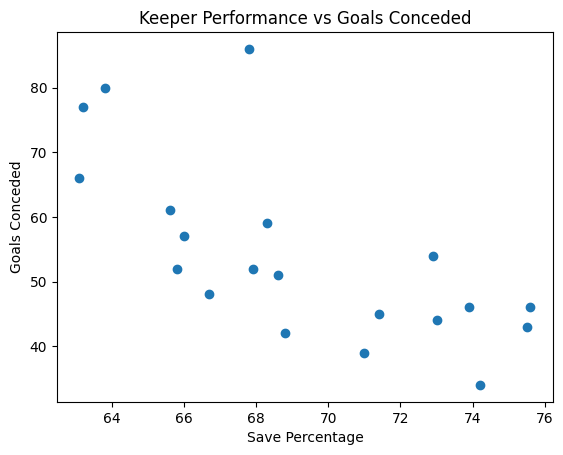

In [23]:
plt.figure()

plt.scatter(
    team_extended["save_pct"],
    team_extended["goals_conceded"]
)

plt.xlabel("Save Percentage")
plt.ylabel("Goals Conceded")
plt.title("Keeper Performance vs Goals Conceded")

plt.show()

In [24]:
team_extended["keeper_strength"] = (
    team_extended["save_pct"] * 0.7 +
    team_extended["clean_sheets"] * 0.3
)

In [25]:
team_extended.sort_values(
    by="keeper_strength",
    ascending=False
)[["team", "keeper_strength"]].head()

,team,keeper_strength
5,Chelsea,56.15
0,Arsenal,55.84
15,Nottingham Forest,55.63
2,Bournemouth,55.62
7,Everton,54.70


In [26]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

cols_to_scale = [
    "goals",
    "goals_conceded",
    "save_pct",
    "clean_sheets"
]

team_extended_scaled = team_extended.copy()

team_extended_scaled[cols_to_scale] = scaler.fit_transform(
    team_extended[cols_to_scale]
)

team_extended_scaled.head()

,team,# Pl,90s,goals,shots,Standard_SoT,Standard_SoT%,Standard_Sh/90,Standard_SoT/90,Standard_G/Sh,Standard_G/SoT,Standard_PK,Standard_PKatt,goals_conceded,save_pct,clean_sheets,keeper_strength
0,Arsenal,25,38.0,0.700000,544,178,32.7,14.32,4.68,0.12,0.37,2,2,0.000000,0.888,0.916667,55.84
1,Aston Villa,28,38.0,0.516667,478,159,33.3,12.58,4.18,0.11,0.33,3,6,0.326923,0.440,0.583333,50.72
2,Bournemouth,29,38.0,0.533333,574,192,33.4,15.11,5.05,0.09,0.27,6,7,0.230769,1.000,0.583333,55.62
3,Brentford,28,38.0,0.666667,434,173,39.9,11.42,4.55,0.14,0.35,5,6,0.384615,0.784,0.500000,53.43
4,Brighton,32,38.0,0.650000,526,183,34.8,13.84,4.82,0.11,0.31,7,7,0.442308,0.232,0.500000,48.60


In [27]:
team_extended_scaled["overall_team_strength"] = (
    team_extended_scaled["goals"] * 0.4
    - team_extended_scaled["goals_conceded"] * 0.3
    + team_extended_scaled["save_pct"] * 0.2
    + team_extended_scaled["clean_sheets"] * 0.1
)

In [28]:
final_ranking = team_extended_scaled.sort_values(
    by="overall_team_strength",
    ascending=False
)

final_ranking[["team", "overall_team_strength"]]

,team,overall_team_strength
11,Liverpool,0.597554
0,Arsenal,0.549267
5,Chelsea,0.461477
12,Manchester City,0.443379
14,Newcastle United,0.434338
15,Nottingham Forest,0.408569
2,Bournemouth,0.402436
3,Brentford,0.358082
7,Everton,0.277374
1,Aston Villa,0.254923


In [29]:
final_ranking[[
    "team",
    "goals",
    "goals_conceded",
    "save_pct",
    "clean_sheets",
    "overall_team_strength"
]].head(5)

,team,goals,goals_conceded,save_pct,clean_sheets,overall_team_strength
11,Liverpool,1.000000,0.096154,0.632,1.000000,0.597554
0,Arsenal,0.700000,0.000000,0.888,0.916667,0.549267
5,Chelsea,0.600000,0.173077,0.992,0.750000,0.461477
12,Manchester City,0.766667,0.153846,0.456,0.916667,0.443379
14,Newcastle United,0.683333,0.211538,0.664,0.916667,0.434338


In [30]:
playing_time = pd.read_csv(
    r"../data/overwiev__stats_squads_playing_time_for.csv"
)

playing_time.head()

,Squad,# Pl,Age,Playing Time_MP,Playing Time_Min,Playing Time_Mn/MP,Playing Time_Min%,Playing Time_90s,Starts_Starts,Starts_Mn/Start,Starts_Compl,Subs_Subs,Subs_Mn/Sub,Subs_unSub,Team Success_PPM,Team Success_onG,Team Success_onGA,Team Success_+/-,Team Success_+/-90
0,Arsenal,25,25.8,38,3420,90,100,38.0,418,83,272,142,18,200,1.95,69,34,35,0.92
1,Aston Villa,28,27.0,38,3420,90,100,38.0,418,80,246,170,23,170,1.74,58,51,7,0.18
2,Bournemouth,29,25.1,38,3420,90,100,38.0,418,83,254,162,18,180,1.47,58,46,12,0.32
3,Brentford,28,25.8,38,3420,90,100,38.0,418,85,277,142,15,200,1.47,66,57,9,0.24
4,Brighton,32,24.8,38,3420,90,100,38.0,418,82,231,184,18,158,1.61,66,59,7,0.18


In [31]:
playing_time.columns

Index(['Squad', '# Pl', 'Age', 'Playing Time_MP', 'Playing Time_Min',
       'Playing Time_Mn/MP', 'Playing Time_Min%', 'Playing Time_90s',
       'Starts_Starts', 'Starts_Mn/Start', 'Starts_Compl', 'Subs_Subs',
       'Subs_Mn/Sub', 'Subs_unSub', 'Team Success_PPM', 'Team Success_onG',
       'Team Success_onGA', 'Team Success_+/-', 'Team Success_+/-90'],
      dtype='str')

In [32]:
playing_time = playing_time.rename(columns={
    "Squad": "team",
    "# Pl": "players_used",
    "Playing_Time_MP": "matches_played",
    "Playing_Time_Min": "minutes_played",
    "Playing_Time_90s": "total_90s",
    "Subs_Subs": "subs_made",
    "Team Success_+/-": "goal_difference",
    "Team Success_+/-90": "goal_diff_per_90"
})

playing_time["team"] = playing_time["team"].str.strip()

playing_time.head()

,team,players_used,Age,Playing Time_MP,Playing Time_Min,Playing Time_Mn/MP,Playing Time_Min%,Playing Time_90s,Starts_Starts,Starts_Mn/Start,Starts_Compl,subs_made,Subs_Mn/Sub,Subs_unSub,Team Success_PPM,Team Success_onG,Team Success_onGA,goal_difference,goal_diff_per_90
0,Arsenal,25,25.8,38,3420,90,100,38.0,418,83,272,142,18,200,1.95,69,34,35,0.92
1,Aston Villa,28,27.0,38,3420,90,100,38.0,418,80,246,170,23,170,1.74,58,51,7,0.18
2,Bournemouth,29,25.1,38,3420,90,100,38.0,418,83,254,162,18,180,1.47,58,46,12,0.32
3,Brentford,28,25.8,38,3420,90,100,38.0,418,85,277,142,15,200,1.47,66,57,9,0.24
4,Brighton,32,24.8,38,3420,90,100,38.0,418,82,231,184,18,158,1.61,66,59,7,0.18


In [34]:
playing_time.rename(
    columns={"Playing_Time_MP": "matches_played"},
    inplace=True
)

In [35]:
playing_time.columns

Index(['team', 'players_used', 'Age', 'Playing Time_MP', 'Playing Time_Min',
       'Playing Time_Mn/MP', 'Playing Time_Min%', 'Playing Time_90s',
       'Starts_Starts', 'Starts_Mn/Start', 'Starts_Compl', 'subs_made',
       'Subs_Mn/Sub', 'Subs_unSub', 'Team Success_PPM', 'Team Success_onG',
       'Team Success_onGA', 'goal_difference', 'goal_diff_per_90'],
      dtype='str')

In [36]:
playing_time["rotation_index"] = (
    playing_time["players_used"] /
    playing_time["matches_played"]
)

playing_time["sub_intensity"] = (
    playing_time["subs_made"] /
    playing_time["matches_played"]
)

playing_time[["team", "rotation_index", "sub_intensity"]].head()

KeyError: 'matches_played'